# Experiment 7: Rho-Model Comparison on Synthetic Sparse Coding

Goal: compare VG-SAE, L1-ReLU SAE, TopK SAE, and a deterministic sigmoid-gated SAE on the same synthetic sparse-coding task, using measured `rho_model` as the x-axis. This follows the paper's comparison logic: sweep the sparsity field/control, compute mask-density values, then plot latent-vector generalization error, reconstruction error, selection error, and mask uncertainty against `rho_model`.

Definitions used here:

- VG-SAE mask values are `m = sigmoid(gate_encoder(x))`.
- Gated SAE mask values are its deterministic sigmoid gates.
- TopK mask values are exactly the selected TopK indices from the model definition.
- L1-ReLU primary mask values use a two-component GMM elbow on ReLU activation magnitudes, analogous to the paper's LASSO near-zero/broad-component thresholding. Raw ReLU support is logged separately.
- `generalization_error` is the root-relative error between decoder-matched learned latents and the true sparse code `z`.
- `reconstruction_error` is the held-out root-relative reconstruction error in input space.


In [29]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

style_path = PROJECT_ROOT / "physrev.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


In [2]:
from types import SimpleNamespace

import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture
from sklearn.metrics import average_precision_score, roc_auc_score

from src.evaluate import selection_error, selection_uncertainty
from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_model import (
    GatedSAE, GatedSAEConfig,
    L1ReLUSAE, L1SAEConfig,
    TopKSAE, TopKSAEConfig,
    VGSAEConfig, VariationalGarroteSAE,
)
from src.sae_train import fit_sae
from src.utils import set_seed


## Configuration

`VGSAE_NOTEBOOK_FAST_DEV_RUN=1` shrinks the sweep for smoke execution. For publishable plots, increase `n_experiment_seeds`, `train_steps`, and the control grids.


In [3]:
bool(int(os.environ.get("VGSAE_NOTEBOOK_FAST_DEV_RUN", "0")))

False

In [4]:
FAST_DEV_RUN = bool(int(os.environ.get("VGSAE_NOTEBOOK_FAST_DEV_RUN", "0")))

input_dim = 16
n_features = 32
support_density = 0.1
coherence = 0.3
noise_std = 0.00
frequency_skew = 0.01
amplitude_scale = 1.0

if FAST_DEV_RUN:
    n_experiment_seeds = 1
    seeds = list(range(n_experiment_seeds))
    n_train = 96
    n_test = 96
    train_steps = 4
    history_every = 1
    gamma_values = [0.0, 1.0]
    l1_coefficients = [1.0e-4, 1.0e-3]
    gated_l1_coefficients = [1.0e-4, 1.0e-3]
    topk_values = [1, 2]
else:
    n_experiment_seeds = 5
    seeds = list(range(n_experiment_seeds))
    n_train = 512
    n_test = 512
    train_steps = 1000
    history_every = 25
    # gamma_values = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
    # l1_coefficients = [1.0e-5, 3.0e-5, 1.0e-4, 3.0e-4, 1.0e-3, 3.0e-3, 1.0e-2]
    # gated_l1_coefficients = [1.0e-4, 3.0e-4, 1.0e-3, 3.0e-3, 1.0e-2, 3.0e-2]
    # topk_values = [1, 2, 4, 8, 16, 32, 64, 128]
    gamma_values = [
    12.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0,
    4.0, 3.5, 3.0, 2.5, 2.0, 1.75, 1.5,
    1.25, 1.0, 0.75, 0.5, 0.35, 0.25, 0.125, 0.0,
    -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0,
    ]

    l1_coefficients = [
        1.0, 0.3, 0.1, 0.03, 0.01, 0.003,
        0.001, 3e-4, 1e-4, 3e-5, 1e-5,
        3e-6, 1e-6, 3e-7, 1e-7,
    ]

    gated_l1_coefficients = [
        0.1, 0.07, 0.05, 0.03, 0.02, 0.015, 0.01,
        0.007, 0.005, 0.003, 0.002, 0.0015, 0.001,
        7e-4, 5e-4, 3e-4, 2e-4, 1e-4, 5e-5, 2e-5,
        1e-5, 3e-6, 1e-6, 0.0,
    ]

    topk_values = list(range(1, n_features//2 + 1))

batch_size = 128
lr = 1.0e-2
beta = 1.0
gradient_clip_norm = 1.0
dead_threshold = 1.0e-6
mask_threshold = 0.5

topk_values = sorted({int(k) for k in topk_values if 0 < int(k) <= n_features})
EXP_DIR = OUTPUT_DIR / "exp07_synthetic_sparse_coding_rho_model_comparison"
EXP_DIR.mkdir(parents=True, exist_ok=True)


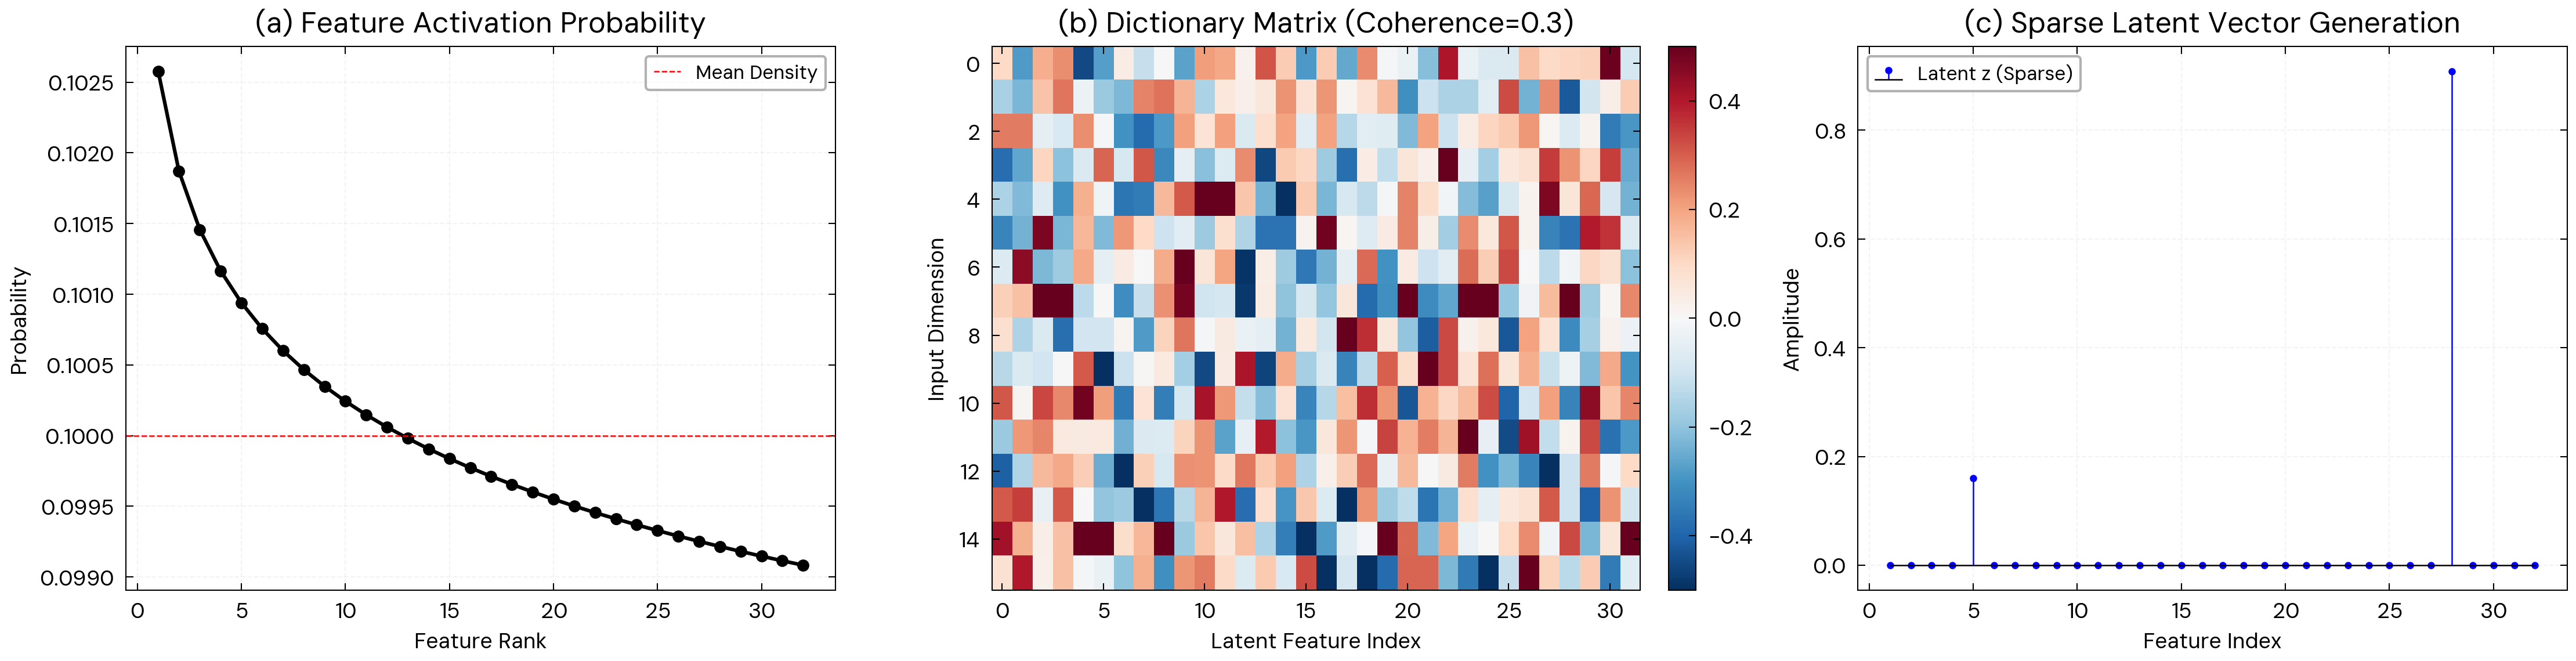

In [5]:
# 하이퍼파라미터 설정 (시각화를 위해 축소된 차원 사용)
# input_dim = 20
# n_features = 50
# support_density = 0.1
# frequency_skew = 1.0
# coherence = 0.3

rng = np.random.default_rng(42)

# 1. Feature Probabilities (Frequency Skew)
ranks = np.arange(1, n_features + 1, dtype=np.float64)
weights = ranks ** (-frequency_skew)
weights /= weights.mean()
probabilities = np.clip(support_density * weights, 0.0, 0.95)

# 2. Dictionary Matrix with Coherence
columns = rng.standard_normal(size=(input_dim, n_features))
common = rng.standard_normal(size=(input_dim, 1))
common /= np.linalg.norm(common, axis=0, keepdims=True)
columns = np.sqrt(coherence) * common + np.sqrt(1.0 - coherence) * columns
dictionary = columns / np.linalg.norm(columns, axis=0, keepdims=True)

# 3. Single Sample Generation (Support, Amplitude, Noise)
support = rng.binomial(1, probabilities)
amplitudes = rng.exponential(scale=1.0, size=n_features)
z = support * amplitudes
clean_x = dictionary @ z
noise = rng.normal(0.0, 0.05, size=input_dim)
x = clean_x + noise

# Figure 생성 (1x3 Layout)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subplot A: Activation Probability
axes[0].plot(ranks, probabilities, 'ko-', markersize=4, linewidth=1.5)
axes[0].axhline(support_density, color='red', linestyle='--', label='Mean Density')
axes[0].set_title('(a) Feature Activation Probability')
axes[0].set_xlabel('Feature Rank')
axes[0].set_ylabel('Probability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot B: Dictionary Matrix
im = axes[1].imshow(dictionary, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1].set_title(f'(b) Dictionary Matrix (Coherence={coherence})')
axes[1].set_xlabel('Latent Feature Index')
axes[1].set_ylabel('Input Dimension')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# Subplot C: Sparse Vector & Observation
axes[2].stem(ranks, z, linefmt='b-', markerfmt='bo', basefmt='k-', label='Latent z (Sparse)')
axes[2].set_title('(c) Sparse Latent Vector Generation')
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
# plt.savefig('synthetic_sparse_coding_method.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [6]:
def split_sparse_coding_data(data, n_train):
    train = SimpleNamespace(
        x=data.x[:n_train],
        z=data.z[:n_train],
        support=data.support[:n_train],
        dictionary=data.dictionary,
        clean_x=data.clean_x[:n_train],
        feature_probabilities=data.feature_probabilities,
    )
    test = SimpleNamespace(
        x=data.x[n_train:],
        z=data.z[n_train:],
        support=data.support[n_train:],
        dictionary=data.dictionary,
        clean_x=data.clean_x[n_train:],
        feature_probabilities=data.feature_probabilities,
    )
    return train, test


def make_train_test(seed):
    data = make_synthetic_sparse_coding(
        SyntheticSparseCodingConfig(
            input_dim=input_dim,
            n_features=n_features,
            n_samples=n_train + n_test,
            support_density=support_density,
            coherence=coherence,
            noise_std=noise_std,
            frequency_skew=frequency_skew,
            amplitude_scale=amplitude_scale,
            seed=seed,
        ),
        device=DEVICE,
    )
    return split_sparse_coding_data(data, n_train)


train0, test0 = make_train_test(seeds[0])
print(
    "train", tuple(train0.x.shape),
    "test", tuple(test0.x.shape),
    "empirical support density", float(train0.support.mean()),
)


train (512, 16) test (512, 16) empirical support density 0.09759521484375


## Mask and Metric Helpers

Learned latents are matched to true sparse-coding features by maximum absolute decoder cosine. Selection metrics are computed after this matching.


In [12]:
METHOD_LABELS = {
    "vgsae": "VG-SAE",
    "l1": "L1-ReLU",
    "topk": "TopK",
    "gated": "Gated",
}
METHOD_COLORS = {
    "vgsae": "tab:blue",
    "l1": "tab:orange",
    "topk": "tab:green",
    "gated": "tab:red",
}


def build_specs():
    specs = []
    specs.extend(
        {
            "method": "vgsae",
            "control_name": "gamma",
            "control_value": float(gamma),
        }
        for gamma in gamma_values
    )
    specs.extend(
        {
            "method": "l1",
            "control_name": "l1_coefficient",
            "control_value": float(coef),
        }
        for coef in l1_coefficients
    )
    specs.extend(
        {
            "method": "topk",
            "control_name": "k",
            "control_value": int(k),
        }
        for k in topk_values
    )
    specs.extend(
        {
            "method": "gated",
            "control_name": "l1_coefficient",
            "control_value": float(coef),
        }
        for coef in gated_l1_coefficients
    )
    return specs


def build_model(spec):
    method = spec["method"]
    value = spec["control_value"]
    if method == "vgsae":
        return VariationalGarroteSAE(
            VGSAEConfig(
                input_dim=input_dim,
                n_latents=n_features,
                lambda_sparsity=float(value),
                beta=beta,
            )
        )
    if method == "l1":
        return L1ReLUSAE(
            L1SAEConfig(
                input_dim=input_dim,
                n_latents=n_features,
                l1_coefficient=float(value),
            )
        )
    if method == "topk":
        return TopKSAE(
            TopKSAEConfig(
                input_dim=input_dim,
                n_latents=n_features,
                k=int(value),
            )
        )
    if method == "gated":
        return GatedSAE(
            GatedSAEConfig(
                input_dim=input_dim,
                n_latents=n_features,
                l1_coefficient=float(value),
            )
        )
    raise ValueError(f"Unknown method: {method}")


def relative_reconstruction_error(x_hat, target, eps=1.0e-12):
    numerator = (x_hat - target).pow(2).sum()
    denominator = target.pow(2).sum().clamp_min(eps)
    return float(torch.sqrt(numerator / denominator).detach().cpu())


def explained_variance_score(x_hat, target, eps=1.0e-12):
    residual = (target - x_hat).pow(2).sum(dim=1).mean()
    target_second_moment = target.pow(2).sum(dim=1).mean()
    target_mean_norm_sq = target.mean(dim=0).pow(2).sum()
    variance = (target_second_moment - target_mean_norm_sq).clamp_min(eps)
    return float((1.0 - residual / variance).detach().cpu())

def average_l0(mask_values, threshold=0.5, mode="threshold"):
    if isinstance(mask_values, torch.Tensor):
        values = mask_values.detach().cpu().numpy()
    else:
        values = np.asarray(mask_values)

    if values.ndim != 2:
        raise ValueError(f"Expected mask_values with shape (batch, n_features), got {values.shape}.")

    if mode == "threshold":
        return float((values >= threshold).sum(axis=1).mean())

    if mode == "expected":
        return float(values.sum(axis=1).mean())

    raise ValueError(f"Unknown mode: {mode!r}. Expected 'threshold' or 'expected'.")

def relative_latent_error(h_hat, z_true, eps=1.0e-12):
    h_hat = np.asarray(h_hat, dtype=np.float64)
    z_true = np.asarray(z_true, dtype=np.float64)
    numerator = np.sum((h_hat - z_true) ** 2)
    denominator = max(float(np.sum(z_true ** 2)), eps)
    return float(np.sqrt(numerator / denominator))


def decoder_matching(model, true_dictionary):
    learned = model.decoder.weight.detach().cpu()
    true = true_dictionary.detach().cpu()
    learned = learned / learned.norm(dim=0, keepdim=True).clamp_min(1.0e-12)
    true = true / true.norm(dim=0, keepdim=True).clamp_min(1.0e-12)
    signed_cosines = (learned.T @ true).numpy()
    cosines = np.abs(signed_cosines)
    learned_idx, true_idx = linear_sum_assignment(-cosines)
    signs = np.sign(signed_cosines[learned_idx, true_idx]) if learned_idx.size else np.array([])
    signs = np.where(signs == 0.0, 1.0, signs)
    recovery = float(cosines[learned_idx, true_idx].mean()) if learned_idx.size else 0.0
    return learned_idx, true_idx, signs, recovery


def align_to_true_features(values, learned_idx, true_idx, n_true, signs=None):
    if isinstance(values, torch.Tensor):
        array = values.detach().cpu().numpy()
    else:
        array = np.asarray(values)
    aligned = np.zeros((array.shape[0], n_true), dtype=np.float64)
    selected = array[:, learned_idx]
    if signs is not None:
        selected = selected * np.asarray(signs, dtype=np.float64)[None, :]
    aligned[:, true_idx] = selected
    return aligned


def l1_gmm_activation_threshold(h):
    values = h.detach().cpu().numpy().reshape(-1, 1)
    if values.size == 0 or np.nanmax(values) <= 0.0:
        return np.inf
    logged = np.log1p(values)
    if float(np.nanmax(logged) - np.nanmin(logged)) < 1.0e-8:
        return 0.0
    try:
        gmm = GaussianMixture(
            n_components=2,
            covariance_type="full",
            means_init=np.array([[0.0], [float(np.percentile(logged, 95.0))]]),
            random_state=0,
        )
        gmm.fit(logged)
        means = np.sort(gmm.means_.reshape(-1))
        return float(max(np.expm1(0.5 * (means[0] + means[-1])), 0.0))
    except Exception:
        positive = values[values[:, 0] > 0.0, 0]
        return float(np.percentile(positive, 50.0)) if positive.size else np.inf


@torch.no_grad()
def latent_values_and_masks(model, x):
    model.eval()
    if isinstance(model, VariationalGarroteSAE):
        output = model(x)
        return output["h"], output["m"], {"mask_family": "bernoulli_probability"}
    if isinstance(model, GatedSAE):
        output = model(x)
        return output["h"], output["gate"], {"mask_family": "sigmoid_gate"}
    if isinstance(model, TopKSAE):
        acts = F.relu(model.encoder(x))
        _, indices = torch.topk(acts, k=model.config.k, dim=1)
        mask = torch.zeros_like(acts)
        mask.scatter_(1, indices, 1.0)
        h = mask * acts
        return h, mask, {"mask_family": "exact_topk"}
    if isinstance(model, L1ReLUSAE):
        h = model.encode(x)
        threshold = l1_gmm_activation_threshold(h)
        mask = (h > threshold).to(x.dtype)
        return h, mask, {
            "mask_family": "gmm_relu_activation",
            "l1_gmm_threshold": threshold,
            "l1_raw_relu_density": float((h > 0.0).to(x.dtype).mean().detach().cpu()),
        }
    raise TypeError(f"Unsupported model type: {type(model).__name__}")


def binary_support_metrics(mask_values, true_support, threshold=0.5):
    pred = mask_values >= threshold
    target = true_support >= 0.5
    tp = np.logical_and(pred, target).sum()
    fp = np.logical_and(pred, np.logical_not(target)).sum()
    fn = np.logical_and(np.logical_not(pred), target).sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2.0 * precision * recall / max(precision + recall, 1.0e-12)
    return float(precision), float(recall), float(f1)


def ranking_support_metrics(mask_values, true_support):
    target = (true_support.reshape(-1) >= 0.5).astype(int)
    scores = mask_values.reshape(-1)
    if target.min() == target.max():
        return np.nan, np.nan
    average_precision = average_precision_score(target, scores)
    roc_auc = roc_auc_score(target, scores)
    return float(average_precision), float(roc_auc)


@torch.no_grad()
def evaluate_trained_model(model, train_data, test_data, spec, seed, run_id):
    train_h, train_mask, train_mask_info = latent_values_and_masks(model, train_data.x)
    test_h, test_mask, test_mask_info = latent_values_and_masks(model, test_data.x)
    output = model(test_data.x)
    learned_idx, true_idx, signs, decoder_recovery = decoder_matching(model, test_data.dictionary)

    mask_aligned = align_to_true_features(test_mask, learned_idx, true_idx, test_data.support.shape[1])
    h_aligned = align_to_true_features(test_h, learned_idx, true_idx, test_data.support.shape[1], signs=signs)
    true_support = test_data.support.detach().cpu().numpy()
    true_z = test_data.z.detach().cpu().numpy()

    precision, recall, f1 = binary_support_metrics(mask_aligned, true_support, threshold=mask_threshold)
    average_precision, roc_auc = ranking_support_metrics(mask_aligned, true_support)
    active = true_z > 1.0e-8
    amplitude_ratio = h_aligned[active] / np.maximum(true_z[active], 1.0e-8) if active.any() else np.array([])
    reconstruction_error = relative_reconstruction_error(output["x_hat"], test_data.x)
    clean_reconstruction_error = relative_reconstruction_error(output["x_hat"], test_data.clean_x)
    explained_variance = explained_variance_score(output["x_hat"], test_data.x)
    avg_l0 = average_l0(mask_aligned, threshold=mask_threshold, mode="threshold")
    expected_l0 = average_l0(mask_aligned, mode="expected")

    row = {
        "run_id": run_id,
        "seed": seed,
        "method": spec["method"],
        "method_label": METHOD_LABELS[spec["method"]],
        "control_name": spec["control_name"],
        "control_value": spec["control_value"],
        "rho_model": float(mask_aligned.mean()),
        "generalization_error": relative_latent_error(h_aligned, true_z),
        "reconstruction_error": reconstruction_error,
        "clean_reconstruction_error": clean_reconstruction_error,
        "explained_variance": explained_variance,
        "reconstruction_mse": float((output["x_hat"] - test_data.x).pow(2).mean().detach().cpu()),
        "selection_error": selection_error(mask_aligned, true_support),
        "mask_uncertainty": float(np.mean(mask_aligned * (1.0 - mask_aligned))),
        "paper_style_sigma_sel": selection_uncertainty(mask_aligned),
        "support_precision": precision,
        "support_recall": recall,
        "support_f1": f1,
        "support_average_precision": average_precision,
        "support_roc_auc": roc_auc,
        "decoder_recovery_cosine": decoder_recovery,
        "dead_fraction": float((train_h.mean(dim=0) <= dead_threshold).to(torch.float32).mean().detach().cpu()),
        "amplitude_shrinkage": float(amplitude_ratio.mean()) if amplitude_ratio.size else np.nan,
        "mean_activation": float(test_h.mean().detach().cpu()),
        "average_l0": avg_l0,
        "expected_l0": expected_l0,
    }
    row.update({k: v for k, v in train_mask_info.items() if not isinstance(v, str)})
    row.update({k: v for k, v in test_mask_info.items() if not isinstance(v, str)})

    if spec["method"] == "l1":
        raw_mask = (test_h > 0.0).to(test_h.dtype)
        raw_aligned = align_to_true_features(raw_mask, learned_idx, true_idx, test_data.support.shape[1])
        row["l1_raw_relu_rho_model"] = float(raw_aligned.mean())
        row["l1_raw_relu_selection_error"] = selection_error(raw_aligned, true_support)
        row["l1_raw_relu_sigma_sel"] = selection_uncertainty(raw_aligned)
    else:
        row["l1_raw_relu_rho_model"] = np.nan
        row["l1_raw_relu_selection_error"] = np.nan
        row["l1_raw_relu_sigma_sel"] = np.nan

    cache = {
        "mask": mask_aligned,
        "true_support": true_support,
        "h": h_aligned,
    }
    return row, cache


## Run the Sweep

Each method is trained over its own sparsity-control grid. The comparison uses the measured mask density `rho_model`, not the raw control value.


In [13]:
final_rows = []
history_rows = []
mask_cache = {}

for seed in seeds:
    train_data, test_data = make_train_test(seed)
    for spec_index, spec in enumerate(build_specs()):
        run_id = f"{spec['method']}_{spec['control_name']}={spec['control_value']}_seed={seed}"
        print("training", run_id)
        init_seed = 100_000 + 1_000 * seed + spec_index
        set_seed(init_seed)
        model = build_model(spec)
        result = fit_sae(
            model,
            train_data.x,
            lr=lr,
            batch_size=batch_size,
            max_steps=train_steps,
            gradient_clip_norm=gradient_clip_norm,
            history_every=history_every,
            seed=init_seed,
        )
        row, cache = evaluate_trained_model(model, train_data, test_data, spec, seed, run_id)
        final_rows.append(row)
        mask_cache[run_id] = cache
        for hrow in result.history:
            history_rows.append({
                "run_id": run_id,
                "seed": seed,
                "method": spec["method"],
                "method_label": METHOD_LABELS[spec["method"]],
                "control_name": spec["control_name"],
                "control_value": spec["control_value"],
                **hrow,
            })

final_df = pd.DataFrame(final_rows).sort_values(["method", "rho_model"]).reset_index(drop=True)
history_df = pd.DataFrame(history_rows)

seed_mean_group_cols = ["method", "method_label", "control_name", "control_value"]
seed_mean_metric_cols = [
    col for col in final_df.select_dtypes(include=np.number).columns
    if col not in {"seed", "control_value"}
]
final_seed_mean_df = (
    final_df
    .groupby(seed_mean_group_cols, as_index=False)
    .agg({**{col: "mean" for col in seed_mean_metric_cols}, "seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
    .sort_values(["method", "rho_model"])
    .reset_index(drop=True)
)
final_df


training vgsae_gamma=12.0_seed=0
training vgsae_gamma=10.0_seed=0
training vgsae_gamma=9.0_seed=0
training vgsae_gamma=8.0_seed=0
training vgsae_gamma=7.0_seed=0
training vgsae_gamma=6.0_seed=0
training vgsae_gamma=5.0_seed=0
training vgsae_gamma=4.0_seed=0
training vgsae_gamma=3.5_seed=0
training vgsae_gamma=3.0_seed=0
training vgsae_gamma=2.5_seed=0
training vgsae_gamma=2.0_seed=0
training vgsae_gamma=1.75_seed=0
training vgsae_gamma=1.5_seed=0
training vgsae_gamma=1.25_seed=0
training vgsae_gamma=1.0_seed=0
training vgsae_gamma=0.75_seed=0
training vgsae_gamma=0.5_seed=0
training vgsae_gamma=0.35_seed=0
training vgsae_gamma=0.25_seed=0
training vgsae_gamma=0.125_seed=0
training vgsae_gamma=0.0_seed=0
training vgsae_gamma=-0.1_seed=0
training vgsae_gamma=-0.2_seed=0
training vgsae_gamma=-0.3_seed=0
training vgsae_gamma=-0.4_seed=0
training vgsae_gamma=-0.5_seed=0
training vgsae_gamma=-0.6_seed=0
training vgsae_gamma=-0.7_seed=0
training vgsae_gamma=-0.8_seed=0
training vgsae_gamma=-0

,run_id,seed,method,method_label,control_name,control_value,rho_model,generalization_error,reconstruction_error,clean_reconstruction_error,...,dead_fraction,amplitude_shrinkage,mean_activation,average_l0,expected_l0,l1_raw_relu_rho_model,l1_raw_relu_selection_error,l1_raw_relu_sigma_sel,l1_gmm_threshold,l1_raw_relu_density
0,gated_l1_coefficient=0.1_seed=1,1,gated,Gated,l1_coefficient,0.1,0.046196,1.130065,0.454564,0.454564,...,0.0,1.152532,0.258985,0.072266,1.478272,NaN,NaN,NaN,NaN,NaN
1,gated_l1_coefficient=0.1_seed=4,4,gated,Gated,l1_coefficient,0.1,0.048084,1.183149,0.510812,0.510812,...,0.0,1.242879,0.274079,0.074219,1.538674,NaN,NaN,NaN,NaN,NaN
2,gated_l1_coefficient=0.1_seed=3,3,gated,Gated,l1_coefficient,0.1,0.048255,1.116601,0.373943,0.373943,...,0.0,2.251948,0.267813,0.039062,1.544151,NaN,NaN,NaN,NaN,NaN
3,gated_l1_coefficient=0.1_seed=2,2,gated,Gated,l1_coefficient,0.1,0.051129,1.078398,0.453396,0.453396,...,0.0,3.260254,0.254685,0.160156,1.636138,NaN,NaN,NaN,NaN,NaN
4,gated_l1_coefficient=0.1_seed=0,0,gated,Gated,l1_coefficient,0.1,0.051640,1.086413,0.638370,0.638370,...,0.0,4.077156,0.239035,0.152344,1.652493,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,vgsae_gamma=-0.9_seed=2,2,vgsae,VG-SAE,gamma,-0.9,0.934934,3.315509,0.067559,0.067559,...,0.0,6.121937,1.067337,31.775391,29.917886,NaN,NaN,NaN,NaN,NaN
431,vgsae_gamma=-1.0_seed=3,3,vgsae,VG-SAE,gamma,-1.0,0.937181,3.315759,0.065096,0.065096,...,0.0,-2.719357,1.068348,31.765625,29.989798,NaN,NaN,NaN,NaN,NaN
432,vgsae_gamma=-1.0_seed=1,1,vgsae,VG-SAE,gamma,-1.0,0.945866,3.396699,0.080284,0.080284,...,0.0,3.980423,1.050710,31.894531,30.267706,NaN,NaN,NaN,NaN,NaN
433,vgsae_gamma=-1.0_seed=0,0,vgsae,VG-SAE,gamma,-1.0,0.961426,3.057519,0.077094,0.077094,...,0.0,16.295256,0.994558,31.931641,30.765619,NaN,NaN,NaN,NaN,NaN


In [16]:
final_df.to_csv(EXP_DIR / "final_metrics.csv", index=False)
final_seed_mean_df.to_csv(EXP_DIR / "final_metrics_seed_mean.csv", index=False)
history_df.to_csv(EXP_DIR / "training_curves.csv", index=False)

summary_cols = [
    "method_label", "control_name", "control_value", "n_seeds", "rho_model",
    "generalization_error", "reconstruction_error", "explained_variance", "selection_error",
    "mask_uncertainty", "paper_style_sigma_sel", "support_f1",
    "decoder_recovery_cosine", "support_average_precision", "support_roc_auc",
    "average_l0", "expected_l0"
]
final_seed_mean_df[summary_cols]


,method_label,control_name,control_value,n_seeds,rho_model,generalization_error,reconstruction_error,explained_variance,selection_error,mask_uncertainty,paper_style_sigma_sel,support_f1,decoder_recovery_cosine,support_average_precision,support_roc_auc,average_l0,expected_l0
0,Gated,l1_coefficient,0.10,5,0.049061,1.118925,0.486217,0.732402,0.132992,0.043761,0.046395,0.036910,0.658797,0.225120,0.628807,0.099609,1.569946
1,Gated,l1_coefficient,0.07,5,0.059650,1.129806,0.447797,0.775938,0.140118,0.052300,0.055739,0.055974,0.659225,0.231020,0.623750,0.143750,1.908807
2,Gated,l1_coefficient,0.05,5,0.071218,1.131088,0.343261,0.867857,0.149425,0.061224,0.065474,0.058625,0.641599,0.205890,0.605723,0.187109,2.278978
3,Gated,l1_coefficient,0.03,5,0.093951,1.145850,0.262728,0.923572,0.166201,0.078732,0.083994,0.076807,0.630813,0.210666,0.605917,0.266797,3.006438
4,Gated,l1_coefficient,0.02,5,0.115015,1.158005,0.213289,0.949192,0.182581,0.093128,0.099813,0.099462,0.629437,0.195149,0.588892,0.403125,3.680493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,VG-SAE,gamma,-0.60,5,0.879140,3.396194,0.087964,0.991410,0.799227,0.075182,0.084019,0.181084,0.590991,0.135582,0.562911,31.072266,28.132492
83,VG-SAE,gamma,-0.70,5,0.885564,3.448630,0.080191,0.992783,0.804003,0.074486,0.082340,0.182220,0.592691,0.129343,0.558277,31.317187,28.338045
84,VG-SAE,gamma,-0.80,5,0.911580,3.367737,0.080718,0.992756,0.827214,0.060166,0.066102,0.180973,0.587389,0.126553,0.549154,31.596094,29.170568
85,VG-SAE,gamma,-0.90,5,0.928880,3.261670,0.080318,0.992802,0.840149,0.049738,0.054279,0.182196,0.582167,0.129660,0.555619,31.732422,29.724160


## Reconstruction metrics

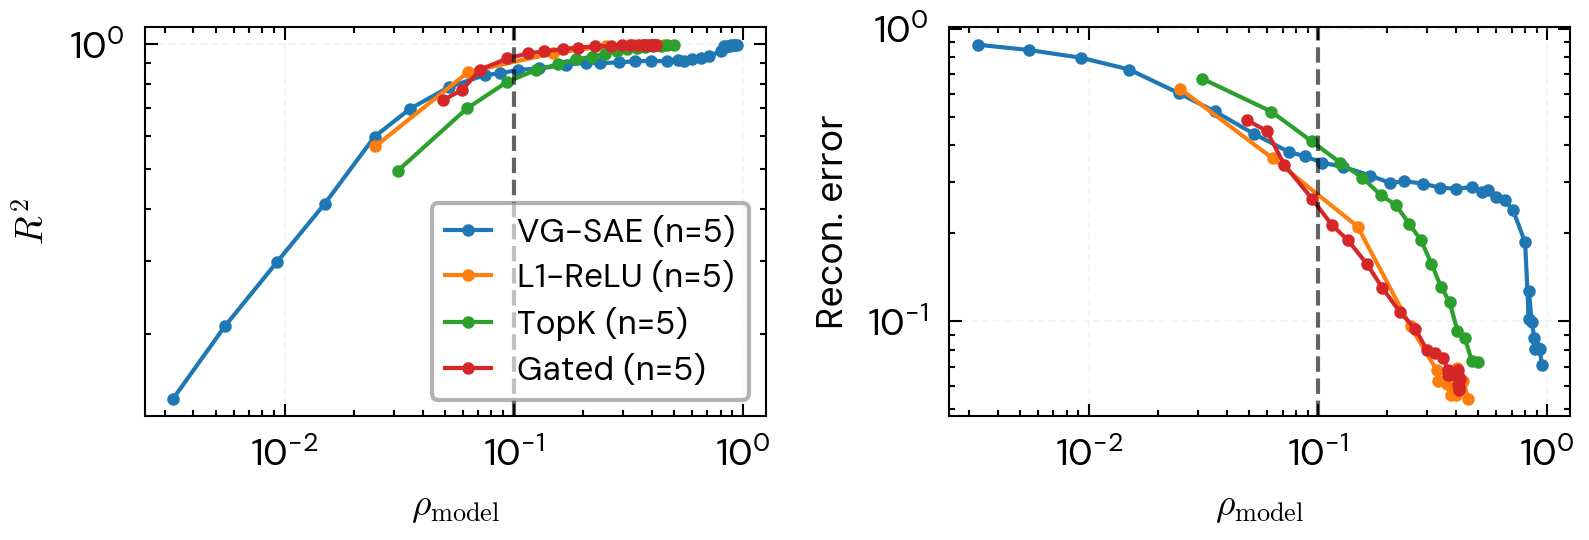

In [32]:
metric_group_cols = ["method", "method_label", "control_name", "control_value"]
metric_cols = [
    col for col in final_df.select_dtypes(include=np.number).columns
    if col not in {"seed", "control_value"}
]

final_seed_mean_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)
    .agg({**{col: "mean" for col in metric_cols}, "seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
)

final_seed_se_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)[metric_cols]
    .sem()
    .fillna(0.0)
    .rename(columns={col: f"{col}_se" for col in metric_cols})
)

final_seed_plot_df = (
    final_seed_mean_df
    .merge(final_seed_se_df, on=metric_group_cols, how="left")
    .sort_values(["method", "rho_model"])
    .reset_index(drop=True)
)

metrics = [
    # ("generalization_error", "Gen. error"),
    ("explained_variance", r'$R^2$'),
    ("reconstruction_error", "Recon. error"),
    # ("selection_error", "Selection error"),
    # ("mask_uncertainty", "mean m(1-m)"),
    # ("paper_style_sigma_sel", "sample-mean mask variance"),
    # ("support_average_precision", "support average precision"),
    # ("decoder_recovery_cosine", "Dict. Cos sim."),
    # ("dead_fraction", "dead latent fraction"),
]

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2), sharex=False)

for ax, (metric, ylabel) in zip(axes.ravel(), metrics):
    for method in ["vgsae", "l1", "topk", "gated"]:
        sub = final_seed_plot_df[final_seed_plot_df["method"] == method].sort_values("rho_model")
        if sub.empty:
            continue

        x = sub["rho_model"].to_numpy(dtype=float)
        y = sub[metric].to_numpy(dtype=float)
        y_se = sub[f"{metric}_se"].to_numpy(dtype=float)

        n_seeds = sorted(sub["n_seeds"].dropna().astype(int).unique())
        label = METHOD_LABELS[method]
        if len(n_seeds) == 1:
            label = f"{label} (n={n_seeds[0]})"

        ax.plot(
            x,
            y,
            marker="o",
            linestyle='-',
            linewidth=1.,
            color=METHOD_COLORS[method],
            label=label,
        )
        # ax.fill_between(
        #     x,
        #     y - y_se,
        #     y + y_se,
        #     color=METHOD_COLORS[method],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    ax.axvline(support_density, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if ax in axes[0]:
        # ax.tick_params(axis="x", which="both", labelbottom=False)
        # ax.set_xlabel("")
    ax.set_xlabel((r'$\rho_\text{model}$'))
for ax in axes.ravel()[len(metrics):]:
    ax.set_visible(False)

axes[0].legend(fontsize=8)
axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())
fig.tight_layout()
# fig.savefig(EXP_DIR / "rho_model_metric_comparison.png", dpi=160)
plt.show()

## Recovery metrics

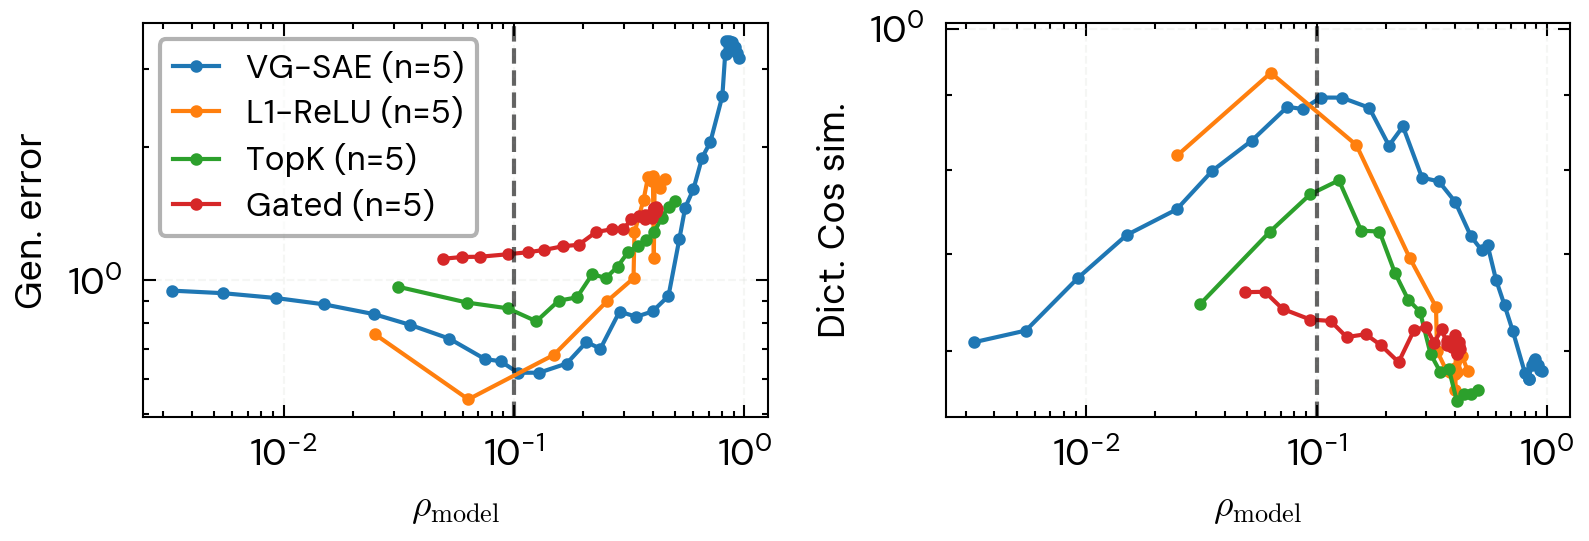

In [43]:
metric_group_cols = ["method", "method_label", "control_name", "control_value"]
metric_cols = [
    col for col in final_df.select_dtypes(include=np.number).columns
    if col not in {"seed", "control_value"}
]

final_seed_mean_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)
    .agg({**{col: "mean" for col in metric_cols}, "seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
)

final_seed_se_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)[metric_cols]
    .sem()
    .fillna(0.0)
    .rename(columns={col: f"{col}_se" for col in metric_cols})
)

final_seed_plot_df = (
    final_seed_mean_df
    .merge(final_seed_se_df, on=metric_group_cols, how="left")
    .sort_values(["method", "rho_model"])
    .reset_index(drop=True)
)

metrics = [
    ("generalization_error", "Gen. error"),
    # ("selection_error", "selection error"),
    ("decoder_recovery_cosine", "Dict. Cos sim."),
]

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2), sharex=False)

for ax, (metric, ylabel) in zip(axes.ravel(), metrics):
    for method in ["vgsae", "l1", "topk", "gated"]:
        sub = final_seed_plot_df[final_seed_plot_df["method"] == method].sort_values("rho_model")
        if sub.empty:
            continue

        x = sub["rho_model"].to_numpy(dtype=float)
        y = sub[metric].to_numpy(dtype=float)
        y_se = sub[f"{metric}_se"].to_numpy(dtype=float)

        n_seeds = sorted(sub["n_seeds"].dropna().astype(int).unique())
        label = METHOD_LABELS[method]
        if len(n_seeds) == 1:
            label = f"{label} (n={n_seeds[0]})"

        ax.plot(
            x,
            y,
            marker="o",
            linestyle='-',
            linewidth=1.,
            color=METHOD_COLORS[method],
            label=label,
        )
        # ax.fill_between(
        #     x,
        #     y - y_se,
        #     y + y_se,
        #     color=METHOD_COLORS[method],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    ax.axvline(support_density, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.set_xscale('log')
    ax.set_yscale('log')
    # if ax in axes[0]:
        # ax.tick_params(axis="x", which="both", labelbottom=False)
        # ax.set_xlabel("")
    ax.set_xlabel((r'$\rho_\text{model}$'))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

for ax in axes.ravel()[len(metrics):]:
    ax.set_visible(False)
axes[1].set_ylim(top=1.01)
axes[0].legend(fontsize=8)
# axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())
fig.tight_layout()
# fig.savefig(EXP_DIR / "rho_model_metric_comparison.png", dpi=160)
plt.show()

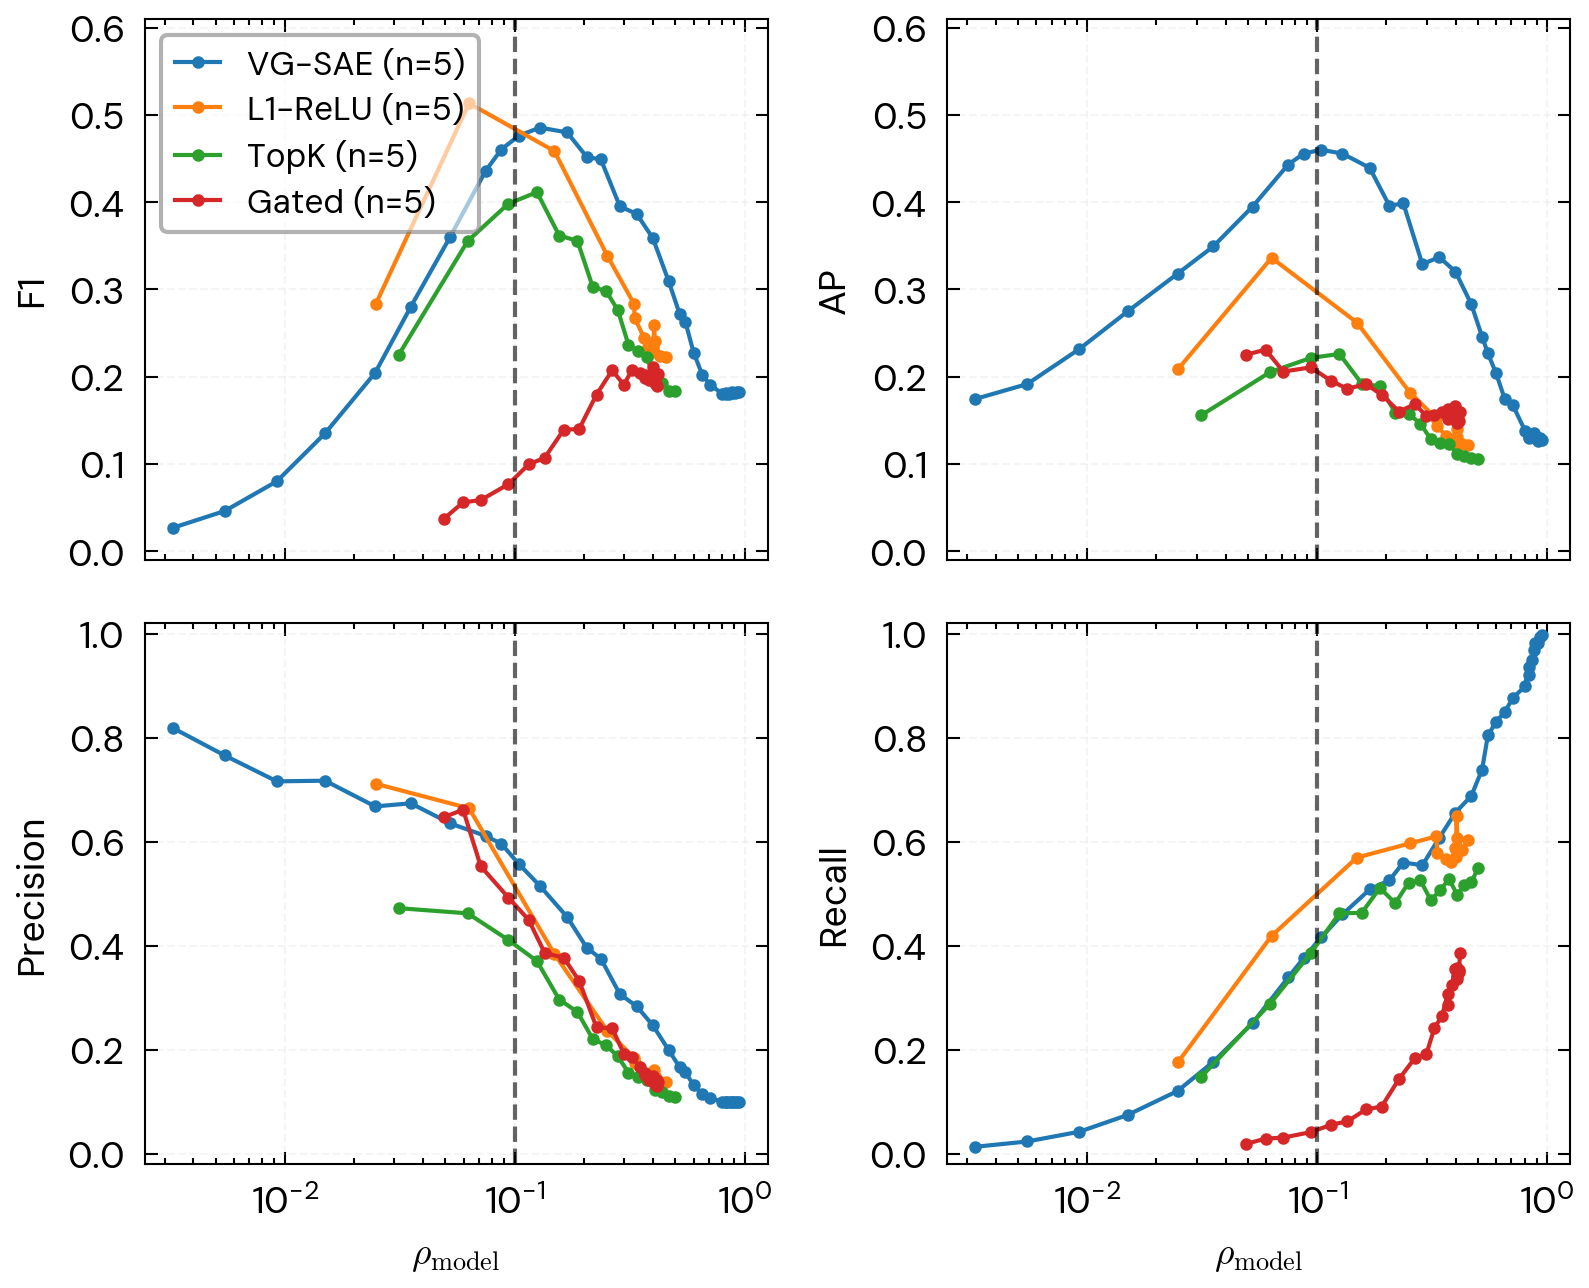

In [72]:
support_group_cols = ["method", "method_label", "control_name", "control_value"]
support_numeric_cols = [
    col for col in final_df.select_dtypes(include=np.number).columns
    if col not in {"seed", "control_value"}
]

final_seed_mean_df = (
    final_df
    .groupby(support_group_cols, as_index=False)
    .agg({**{col: "mean" for col in support_numeric_cols}, "seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
)

final_seed_se_df = (
    final_df
    .groupby(support_group_cols, as_index=False)[support_numeric_cols]
    .sem()
    .fillna(0.0)
    .rename(columns={col: f"{col}_se" for col in support_numeric_cols})
)

final_seed_plot_df = (
    final_seed_mean_df
    .merge(final_seed_se_df, on=support_group_cols, how="left")
    .sort_values(["method", "rho_model"])
    .reset_index(drop=True)
)

support_metrics = [
    ("support_f1", "F1"),
    ("support_average_precision", "AP"),
    ("support_precision", "Precision"),
    ("support_recall", "Recall"),
]

fig, axes = plt.subplots(2, 2, figsize=(5.5, 4.5), sharex=True)

for ax, (metric, ylabel) in zip(axes.ravel(), support_metrics, strict=True):
    for method in ["vgsae", "l1", "topk", "gated"]:
        sub = final_seed_plot_df[final_seed_plot_df["method"] == method].sort_values("rho_model")
        if sub.empty:
            continue

        x = sub["rho_model"].to_numpy(dtype=float)
        y = sub[metric].to_numpy(dtype=float)
        y_se = sub[f"{metric}_se"].to_numpy(dtype=float)

        n_seeds = sorted(sub["n_seeds"].dropna().astype(int).unique())
        label = METHOD_LABELS[method]
        if len(n_seeds) == 1:
            label = f"{label} (n={n_seeds[0]})"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.,
            linestyle='-',
            color=METHOD_COLORS[method],
            label=label,
        )
        # ax.fill_between(
        #     x,
        #     y - y_se,
        #     y + y_se,
        #     color=METHOD_COLORS[method],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    ax.axvline(support_density, color="black", linestyle="--", linewidth=1, alpha=0.6)
    # ax.set_xlabel("rho_model")
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.set_xscale('log')
    if ax in axes[0]:
        ax.set_ylim(top=0.61, bottom=-0.01)
    if ax in axes[1]:
        ax.set_xlabel((r'$\rho_\text{model}$'))

axes[0, 0].legend(fontsize=8)
fig.tight_layout()
# fig.savefig(EXP_DIR / "rho_model_support_diagnostics.png", dpi=160)
plt.show()

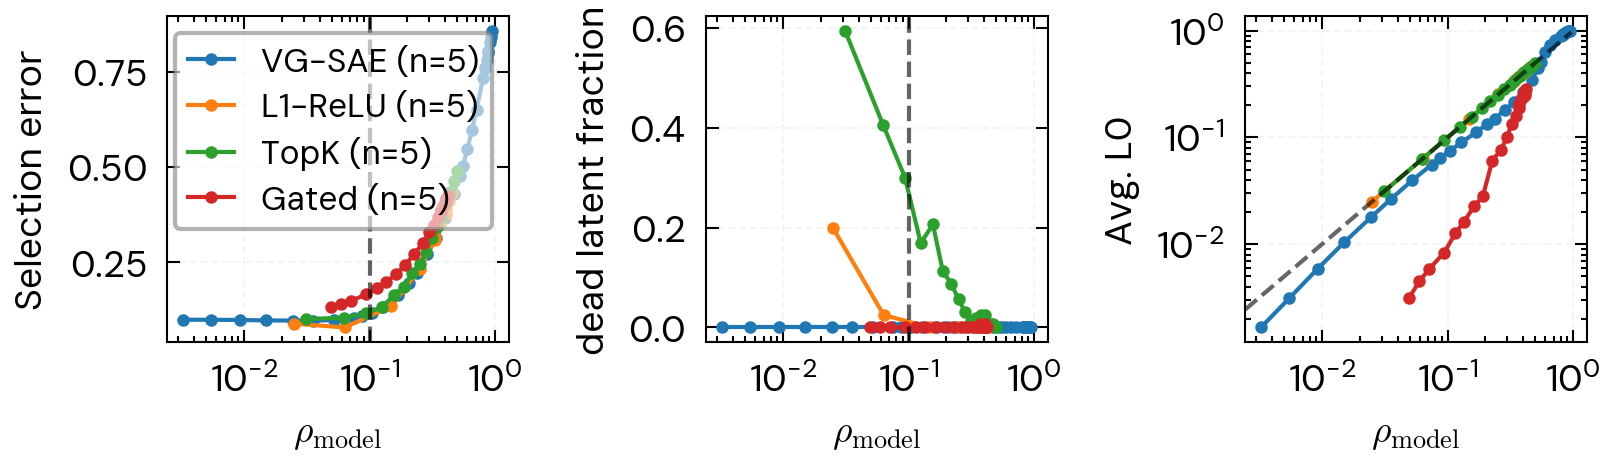

In [77]:
metric_group_cols = ["method", "method_label", "control_name", "control_value"]
metric_cols = [
    col for col in final_df.select_dtypes(include=np.number).columns
    if col not in {"seed", "control_value"}
]

final_seed_mean_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)
    .agg({**{col: "mean" for col in metric_cols}, "seed": "nunique"})
    .rename(columns={"seed": "n_seeds"})
)

final_seed_se_df = (
    final_df
    .groupby(metric_group_cols, as_index=False)[metric_cols]
    .sem()
    .fillna(0.0)
    .rename(columns={col: f"{col}_se" for col in metric_cols})
)

final_seed_plot_df = (
    final_seed_mean_df
    .merge(final_seed_se_df, on=metric_group_cols, how="left")
    .sort_values(["method", "rho_model"])
    .reset_index(drop=True)
)

metrics = [
    ("selection_error", "Selection error"),
    # ("mask_uncertainty", "mean m(1-m)"),
    # ("paper_style_sigma_sel", "sample-mean mask variance"),
    ("dead_fraction", "dead latent fraction"),
    ("average_l0", "Avg. L0"),
    ("expected_l0", "Exp. L0")
]

fig, axes = plt.subplots(1, 3, figsize=(5.5, 1.75), sharex=True)

for ax, (metric, ylabel) in zip(axes.ravel(), metrics):
    for method in ["vgsae", "l1", "topk", "gated"]:
        sub = final_seed_plot_df[final_seed_plot_df["method"] == method].sort_values("rho_model")
        if sub.empty:
            continue

        x = sub["rho_model"].to_numpy(dtype=float)
        y = sub[metric].to_numpy(dtype=float)
        y_se = sub[f"{metric}_se"].to_numpy(dtype=float)

        n_seeds = sorted(sub["n_seeds"].dropna().astype(int).unique())
        label = METHOD_LABELS[method]
        if len(n_seeds) == 1:
            label = f"{label} (n={n_seeds[0]})"
        if ylabel=='Avg. L0':
            y = y/n_features
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.,
            linestyle='-',
            color=METHOD_COLORS[method],
            label=label,
        )
        # ax.fill_between(
        #     x,
        #     y - y_se,
        #     y + y_se,
        #     color=METHOD_COLORS[method],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    if ax in [axes[0], axes[1]]:
        ax.axvline(support_density, color="black", linestyle="--", linewidth=1, alpha=0.6)
    # ax.set_xlabel("rho_model")
    ax.set_ylabel(ylabel)
    # ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.set_xscale('log')
    # if ax in axes[0]:
        # ax.set_ylim(top=0.61, bottom=-0.01)
    ax.set_xlabel((r'$\rho_\text{model}$'))
axes[2].plot(np.arange(n_features)/n_features, np.arange(n_features)/n_features, color="black", linestyle="--", linewidth=1, alpha=0.6)

axes[2].set_yscale('log')

axes[0].legend(fontsize=8)

fig.tight_layout()
# fig.savefig(EXP_DIR / "rho_model_support_diagnostics.png", dpi=160)
plt.show()

## Training curves

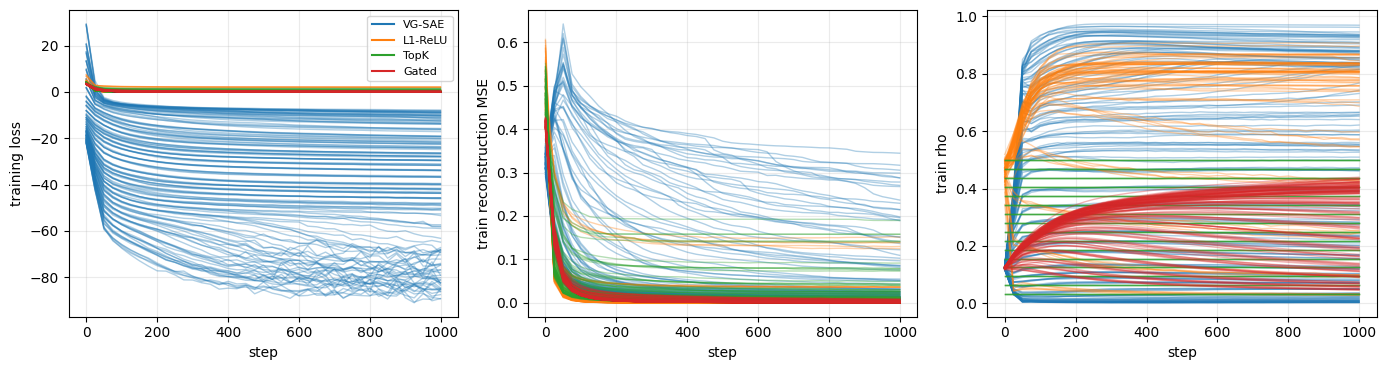

In [13]:
curve_metrics = [
    ("loss", "training loss"),
    ("reconstruction_mse", "train reconstruction MSE"),
    ("rho", "train rho"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (metric, ylabel) in zip(axes, curve_metrics, strict=True):
    for method in ["vgsae", "l1", "topk", "gated"]:
        sub = history_df[history_df["method"] == method]
        if sub.empty or metric not in sub.columns:
            continue
        for _, run in sub.groupby("run_id"):
            run = run.sort_values("step")
            ax.plot(
                run["step"],
                run[metric],
                color=METHOD_COLORS[method],
                alpha=0.35,
                linewidth=1,
            )
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

handles = [
    plt.Line2D([0], [0], color=METHOD_COLORS[m], label=METHOD_LABELS[m])
    for m in ["vgsae", "l1", "topk", "gated"]
]
axes[0].legend(handles=handles, fontsize=8)
fig.tight_layout()
fig.savefig(EXP_DIR / "training_curves.png", dpi=160)


## Representative Mask Heatmaps

For each method, pick the run whose measured `rho_model` is closest to the true support density. This is a sanity check for whether the same density corresponds to the same sample-feature structure.


,method_label,control_name,control_value,rho_model,selection_error
19,Gated,l1_coefficient,0.03,0.097176,0.165088
130,L1-ReLU,l1_coefficient,0.10,0.129456,0.122498
205,TopK,k,3.00,0.093750,0.104004
320,VG-SAE,gamma,3.50,0.100491,0.120538


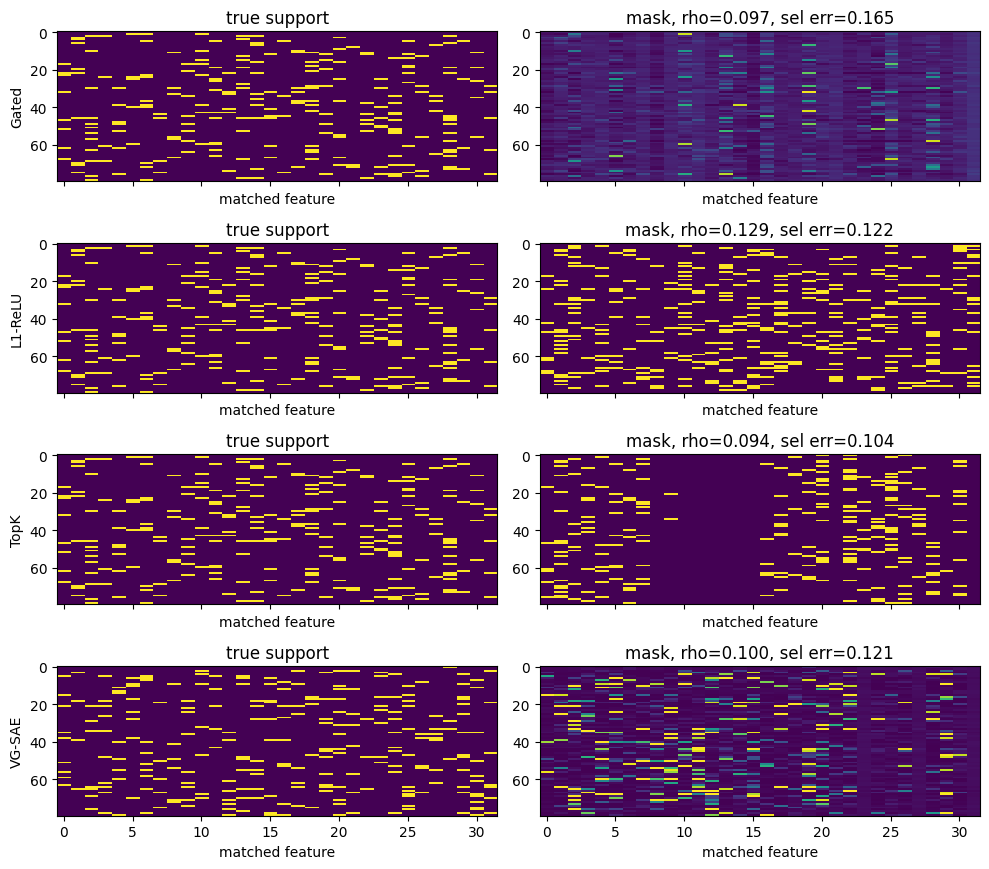

In [14]:
representatives = []
for method, sub in final_df.groupby("method"):
    idx = (sub["rho_model"] - support_density).abs().idxmin()
    representatives.append(final_df.loc[idx])
representatives = pd.DataFrame(representatives).sort_values("method")

n_show = min(80, n_test)
fig, axes = plt.subplots(len(representatives), 2, figsize=(10, 2.2 * len(representatives)), sharex=True)
if len(representatives) == 1:
    axes = np.asarray([axes])

for row_i, (_, row) in enumerate(representatives.iterrows()):
    cache = mask_cache[row["run_id"]]
    axes[row_i, 0].imshow(cache["true_support"][:n_show], aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    axes[row_i, 0].set_ylabel(row["method_label"])
    axes[row_i, 0].set_title("true support")
    axes[row_i, 1].imshow(cache["mask"][:n_show], aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    axes[row_i, 1].set_title(
        f"mask, rho={row['rho_model']:.3f}, sel err={row['selection_error']:.3f}"
    )

for ax in axes.ravel():
    ax.set_xlabel("matched feature")
fig.tight_layout()
fig.savefig(EXP_DIR / "mask_heatmaps.png", dpi=160)
representatives[["method_label", "control_name", "control_value", "rho_model", "selection_error"]]


## Minimal Interpretation Checklist

- The fair comparison is by measured `rho_model`, not by `gamma`, `k`, or L1 coefficient.
- If TopK dominates at the correct density, VG-SAE's probabilistic mask is not buying selection quality on this synthetic setting.
- If VG-SAE has higher `mask_uncertainty` near the true support density while also improving support F1 or clean error, the uncertainty variable is doing useful work rather than merely softening a bad mask.
- L1's raw ReLU support is usually too dense; the GMM elbow columns show whether the paper-style threshold fixes that or just hides the density mismatch.


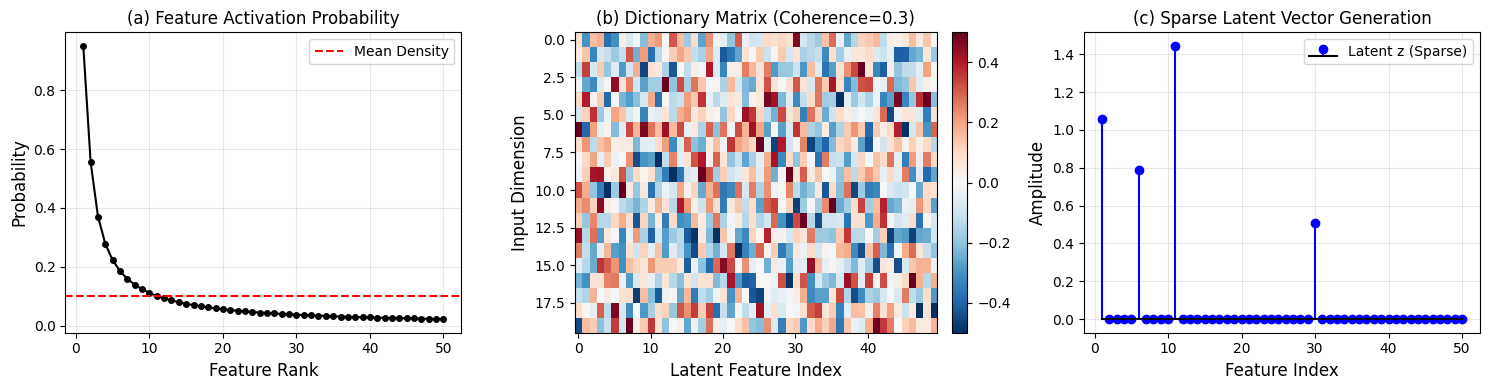

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 논문용 Figure 스타일 설정
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

def visualize_synthetic_sparse_coding():
    # 하이퍼파라미터 설정 (시각화를 위해 축소된 차원 사용)
    input_dim = 20
    n_features = 50
    support_density = 0.1
    frequency_skew = 1.0
    coherence = 0.3
    
    rng = np.random.default_rng(42)
    
    # 1. Feature Probabilities (Frequency Skew)
    ranks = np.arange(1, n_features + 1, dtype=np.float64)
    weights = ranks ** (-frequency_skew)
    weights /= weights.mean()
    probabilities = np.clip(support_density * weights, 0.0, 0.95)
    
    # 2. Dictionary Matrix with Coherence
    columns = rng.standard_normal(size=(input_dim, n_features))
    common = rng.standard_normal(size=(input_dim, 1))
    common /= np.linalg.norm(common, axis=0, keepdims=True)
    columns = np.sqrt(coherence) * common + np.sqrt(1.0 - coherence) * columns
    dictionary = columns / np.linalg.norm(columns, axis=0, keepdims=True)
    
    # 3. Single Sample Generation (Support, Amplitude, Noise)
    support = rng.binomial(1, probabilities)
    amplitudes = rng.exponential(scale=1.0, size=n_features)
    z = support * amplitudes
    clean_x = dictionary @ z
    noise = rng.normal(0.0, 0.05, size=input_dim)
    x = clean_x + noise

    # Figure 생성 (1x3 Layout)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Subplot A: Activation Probability
    axes[0].plot(ranks, probabilities, 'ko-', markersize=4, linewidth=1.5)
    axes[0].axhline(support_density, color='red', linestyle='--', label='Mean Density')
    axes[0].set_title('(a) Feature Activation Probability')
    axes[0].set_xlabel('Feature Rank')
    axes[0].set_ylabel('Probability')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Subplot B: Dictionary Matrix
    im = axes[1].imshow(dictionary, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[1].set_title(f'(b) Dictionary Matrix (Coherence={coherence})')
    axes[1].set_xlabel('Latent Feature Index')
    axes[1].set_ylabel('Input Dimension')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Subplot C: Sparse Vector & Observation
    axes[2].stem(ranks, z, linefmt='b-', markerfmt='bo', basefmt='k-', label='Latent z (Sparse)')
    axes[2].set_title('(c) Sparse Latent Vector Generation')
    axes[2].set_xlabel('Feature Index')
    axes[2].set_ylabel('Amplitude')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    # plt.savefig('synthetic_sparse_coding_method.pdf', format='pdf', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    visualize_synthetic_sparse_coding()